In [1]:
import anndata as ad
import pandas as pd
import scanpy as sc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import numpy as np

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="No data for colormapping provided via 'c'")

In [3]:
adata_transformed = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/combined_samples_scvelo/data/processed/epi_adata_clustered_(32,18)_(0.25,2).h5ad")

In [4]:
gray_green = LinearSegmentedColormap.from_list(
    "gray_green", ["#D3D3D3", "#02500e", "#001203"]
)
gray_orange = LinearSegmentedColormap.from_list(
    "gray_orange", ["#D3D3D3", "#f76d48", "#FA4616"]
)

In [11]:
#importing subset from loupe
barcodes = pd.read_csv("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/combined_samples_scvelo/data/external/epi_adata_clustered_doubled_(32,18)_(0.25,2).csv")["Barcode"].tolist()
sample_number_to_prefix_and_sample = {
    "1": ("plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ", "p4"),
    "2": ("plus345_1_v5e_062522_forced6k_possorted_genome_bam_RL5DI", "p5_1"),
    "3": ("plus345_2_v5e_062522_forced6k_possorted_genome_bam_6EON9", "p5_2"),
    "4": ("minus4_v5e_062522_forced6k_possorted_genome_bam_GWFTD", "m4"),
    "5": ("minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D", "m5")
}

def convert_barcode(bc):
    barcode_part, sample_number = bc.split("-")
    prefix, sample = sample_number_to_prefix_and_sample[sample_number]
    return f"{prefix}:{barcode_part}x"

barcodes_full = pd.Series(barcodes).apply(convert_barcode).tolist()
adata_subset = adata_transformed[adata_transformed.obs_names.isin(barcodes_full)].copy()

In [12]:
adata_subset

AnnData object with n_obs × n_vars = 6046 × 28419
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [13]:
p4_sample = adata_subset[adata_subset.obs["sample"] == "p4"]
print(p4_sample.X.shape)
print((p4_sample[:, "egfp"].X > 0).sum())

(1140, 28419)
32


In [14]:
#save point
adata_subset_test=adata_subset.copy()

In [ ]:
# --- USER PARAMETERS ---
n_pcs_list = [10, 12, 15, 18, 21, 24, 27, 30, 32, 34, 36, 38, 40, 45, 50]
n_neighbors_list = [10, 12, 15, 18, 21, 24, 27, 30, 32, 34, 36, 38, 40, 45, 50]
n_jobs = 8                # Adjust based on memory (10 x ~4GB = ~40GB usage)
batch_size = n_jobs        # Jobs per batch = number of parallel workers

resolution = 0.3
point_size = 20
max_pcs = max(n_pcs_list)

# --- INPUT DATA ---
adata_subset_test = adata_subset.copy()
sc.tl.pca(adata_subset_test, n_comps=50)
adata_temp = adata_subset_test.copy()


# --- GRID ---
param_grid = [(pcs, nn) for pcs in n_pcs_list for nn in n_neighbors_list]
n_total = len(param_grid)
n_batches = int(np.ceil(n_total / batch_size))

# --- UMAP Function ---
def compute_umap_npc_nn(n_pcs, n_neighbors):
    adata_temp = adata_subset_test.copy()
    sc.pp.neighbors(adata_temp, n_neighbors=n_neighbors, n_pcs=n_pcs)
    sc.tl.umap(adata_temp)
    sc.tl.leiden(adata_temp, resolution=resolution)
    return adata_temp, n_pcs, n_neighbors

# --- RUN BATCHES ---
for batch_i in range(n_batches):
    start = batch_i * batch_size
    end = min((batch_i + 1) * batch_size, n_total)
    batch = param_grid[start:end]

    print(f"\n▶ Batch {batch_i+1}/{n_batches} | Combos {start+1}–{end}")
    print(adata_temp.obs["leiden"].value_counts(dropna=False))

    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_umap_npc_nn)(pcs, nn) for pcs, nn in batch
    )

    # Grid dimensions
    unique_pcs = sorted(set(pcs for pcs, _ in batch))
    unique_nn = sorted(set(nn for _, nn in batch))
    n_rows = len(unique_pcs)
    n_cols = len(unique_nn)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5), sharex=True, sharey=True)

    # If only one row or col, axes is not 2D
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    for i, (adata_temp, n_pcs, n_neighbors) in enumerate(results):
        row = unique_pcs.index(n_pcs)
        col = unique_nn.index(n_neighbors)
        ax = axes[row, col]

        sc.pl.umap(
            adata_temp,
            color="leiden",
            title=f"pcs={n_pcs}, nn={n_neighbors}",
            ax=ax,
            show=False,
            legend_loc="on data",
            size=point_size,
            cmap="viridis"
        )
        ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()

In [ ]:
# Set UMAP parameter grid
min_dist_list = [0.0005, 0.001, 0.002, 0.005,0.01, 0.025, 0.05,.06,0.07, 0.08, 0.1,.12,0.15, 0.18, 0.2, 0.25, 0.3,
    0.35, 0.4,.45,0.5,.55 ,0.6,.65, 0.7, 0.8,.85, 0.9, 1.0]

spread_list = [
    0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4,
    1.5, 1.6, 1.7, 1.8, 1.9, 2.0,
    2.1, 2.2, 2.3, 2.5
]
n_jobs = 8
batch_size = n_jobs

n_pcs = 32
n_neighbors = 18

resolution = 0.3
point_size = max(10, 60 - 5 * max(len(min_dist_list), len(spread_list)))

# --- INPUT DATA ---
adata_transformed = adata_subset.copy()

sc.tl.pca(adata_transformed, n_comps=50)
adata_temp = adata_transformed.copy()

# --- GRID ---
param_grid = [(md, sp) for md in min_dist_list for sp in spread_list]
n_total = len(param_grid)
n_batches = int(np.ceil(n_total / batch_size))

# --- UMAP Function ---
def compute_umap_data(min_dist, spread):
    adata_temp = adata_transformed.copy()
    sc.pp.neighbors(adata_temp, n_pcs=n_pcs, n_neighbors=n_neighbors)
    sc.tl.umap(adata_temp, min_dist=min_dist, spread=spread)
    sc.tl.leiden(adata_temp, resolution=resolution)
    return adata_temp, min_dist, spread

# --- RUN BATCHES ---
for batch_i in range(n_batches):
    start = batch_i * batch_size
    end = min((batch_i + 1) * batch_size, n_total)
    batch = param_grid[start:end]

    print(f"\n▶ Batch {batch_i+1}/{n_batches} | Combos {start+1}–{end}")
    print(adata_temp.obs["leiden"].value_counts(dropna=False))
    
    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_umap_data)(md, sp) for md, sp in batch
    )

    # Unique values in this batch (not always full list)
    unique_md = sorted(set(md for md, _ in batch))
    unique_sp = sorted(set(sp for _, sp in batch))
    n_rows = len(unique_md)
    n_cols = len(unique_sp)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5), sharex=True, sharey=True)

    # Handle 1D axis edge cases
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    for i, (adata_temp, min_dist, spread) in enumerate(results):
        row = unique_md.index(min_dist)
        col = unique_sp.index(spread)
        ax = axes[row, col]

        sc.pl.umap(
            adata_temp,
            color="leiden",
            title=f"({n_pcs},{n_neighbors})_min_dist={min_dist}, spread={spread}",
            ax=ax,
            show=False,
            legend_loc="on data",
            size=point_size,
            cmap="viridis"
        )
        ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()

In [ ]:
#testing out different spreads
min_dist_list = [0.1,0.3,0.5,0.7,0.8,0.9]
spread_list = [0.8,1.0, 1.3, 1.6, 1.9, 2.2]
adata_subset_test=adata_subset.copy()
sc.tl.pca(adata_subset_test, n_comps=50)
n_rows = len(min_dist_list)
n_cols = len(spread_list)

fig_width = n_cols * 6
fig_height = n_rows * 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), sharex=True, sharey=True)

point_size = max(10, 60 - 5 * max(n_rows, n_cols))

for row, min_dist in enumerate(min_dist_list):
    for col, spread in enumerate(spread_list):
        ax = axes[row, col]
        adata_temp = adata_subset_test.copy()
        

        sc.tl.pca(adata_temp, n_comps=50)        
        sc.pp.neighbors(adata_temp, n_neighbors=32, n_pcs=40)
        sc.tl.umap(adata_temp, min_dist=min_dist, spread=spread)
        sc.tl.leiden(adata_temp)
        
        sc.pl.umap(
            adata_temp,
            color="leiden",
            title=f"min_dist={min_dist}, spread={spread}",
            cmap="viridis",
            ax=ax,
            show=False,
            size=point_size,
            legend_loc="on top"
        )

for ax in axes.flat:
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


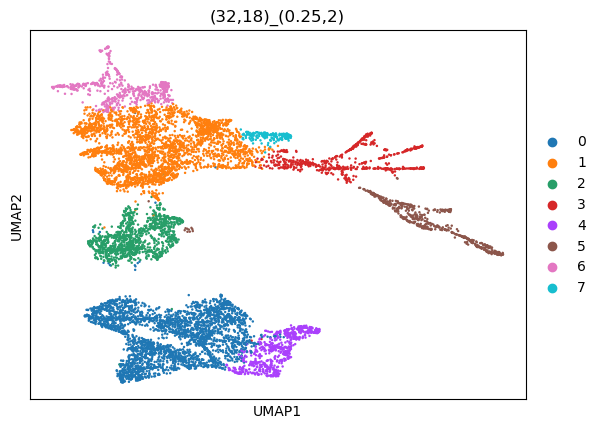

In [10]:
#final subset UMAP
n_pcs=32
n_neighbors=18
min_dist=.25
spread=2
adata_subset_test=adata_subset.copy()
sc.tl.pca(adata_subset_test, n_comps=50, svd_solver='arpack')
sc.pp.neighbors(adata_subset_test, n_pcs=n_pcs, n_neighbors=n_neighbors)  
sc.tl.umap(adata_subset_test,min_dist=min_dist,spread=spread)
sc.tl.leiden(adata_subset_test, resolution=0.3)
sc.pl.umap(adata_subset_test, color="leiden", cmap="viridis", title=f"({n_pcs},{n_neighbors})_({min_dist},{spread})",#legend_loc="on data",
         #save=f"_subset_combined_umap.pdf 
          )

In [11]:
adata_subset_test.write(f"/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/epi_adata_clustered_({n_pcs},{n_neighbors})_({min_dist},{spread}).h5ad")

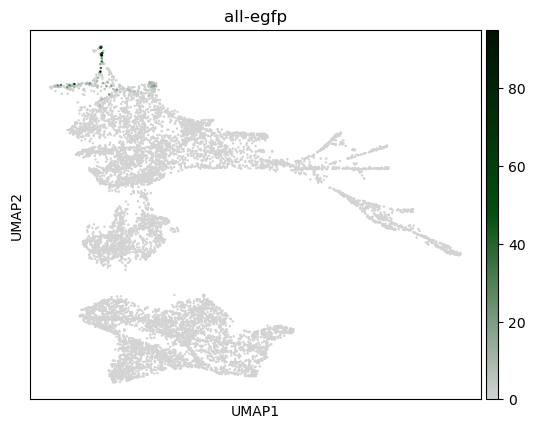

In [12]:
gene="egfp"
sc.pl.umap(
    adata_subset_test,
    color=gene,
    title=f"all-{gene}",
    show=True,
    cmap=gray_green,
       #save=f"_subset_gene_umap_{sample}-{gene}.pdf 
    )

In [ ]:
#testing gene on different samples
gene="calb2a"
for sample in adata_subset_test.obs["sample"].unique():
    sc.pl.umap(
        adata_subset_test[adata_subset_test.obs["sample"] == sample],
        color=gene,
        title=f"{sample}-{gene}",
        show=True,
        cmap=gray_green,
       #save=f"_subset_gene_umap_{sample}-{gene}.pdf 
    )

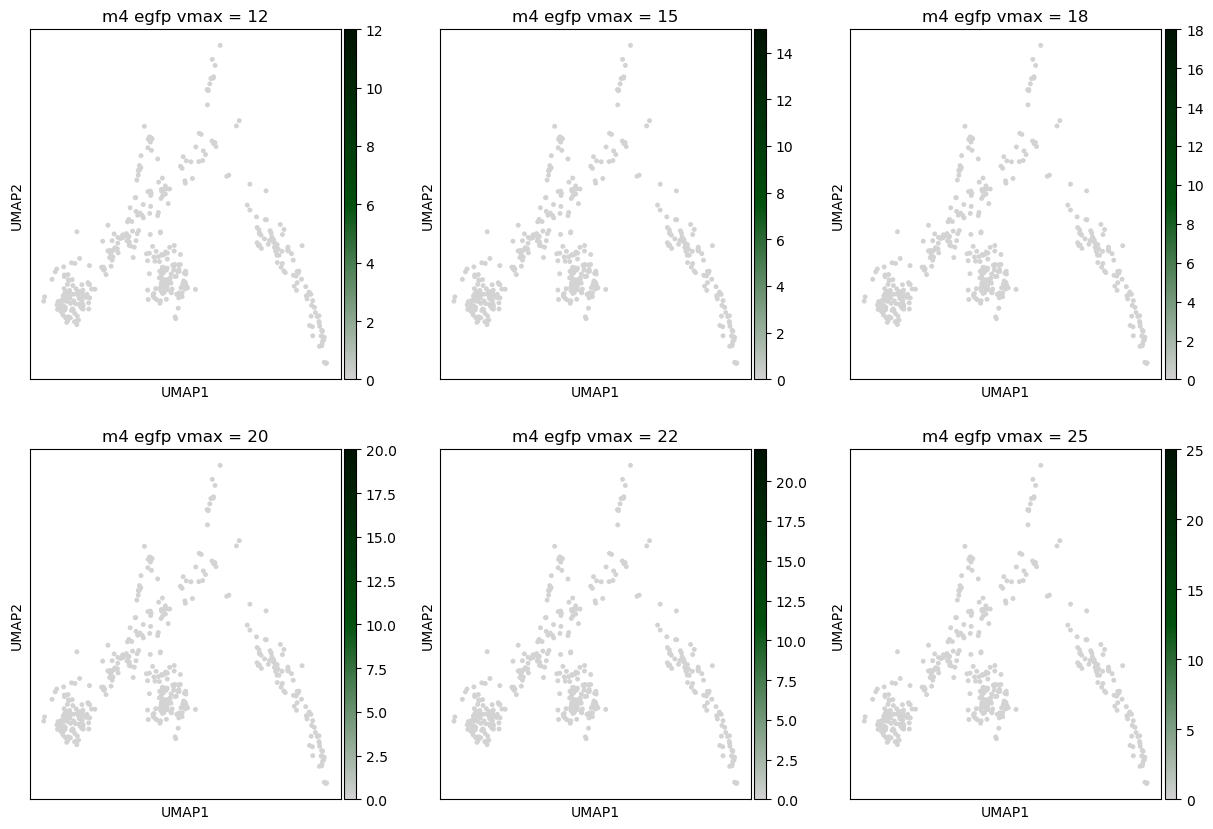

In [35]:
#testing different vmax on same sample
sample='m4'
adata_sample = adata_subset_test[adata_subset_test.obs["sample"] == f"{sample}"].copy()

vmax_values = [12,15,18,20,22,25]
#vmax_values = [2,5,8,10,12,6]

ncols = 3
nrows = (len(vmax_values) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 5 * nrows))

axes = axes.flatten()

for i, vmax in enumerate(vmax_values):
    ax = axes[i]
    sc.pl.umap(
        adata_sample,
        color="egfp",
        vmin=0,
        vmax=vmax,
        size=50,
        title=f"{sample} egfp vmax = {vmax}",
        cmap=gray_green,
        show=False,
        ax=ax  
    )

In [ ]:
sample='m4'
gene='egfp'
adata_sample = adata_subset_test[adata_subset_test.obs["sample"] == f"{sample}"].copy()
sc.pl.umap(
    adata_sample,
    color=gene,
    vmin=0,
    vmax=18,
    size=50,
    title=f'{sample}_{gene}',
    cmap=gray_softorange_orangered,
    #save=f"_subset_umap_{sample}_{gene}.pdf"
)